Aplicación con `data_1.txt`

El archivo `data_1.txt` contiene un conjunto sencillo para regresión lineal. La primera columna corresponde a la variable independiente y la segunda a la variable objetivo.

Los datos representan el precio de una vivienda en función de la población de una ciudad. La población está expresada en unidades de 10.000 habitantes y el precio en unidades de 10.000 dólares.

### Actividad 1

1. Cargue los datos y represéntelos mediante un diagrama de dispersión.
2. Ajuste un modelo `LinearRegression`.
3. Obtenga y muestre el término independiente y la pendiente.
4. Obtenga y muestre los parámetros del modelo.
5. Grafique la recta ajustada sobre los datos.
6. Interprete el signo y la magnitud de la pendiente.

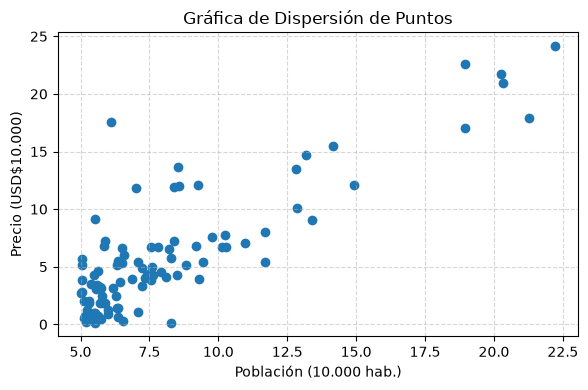

Término independiente  -3.5809620099565436
Pendiente:  1.1697762389135078
Parámetros del modelo:  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


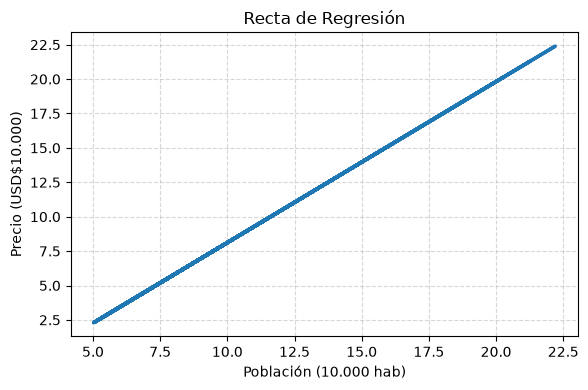

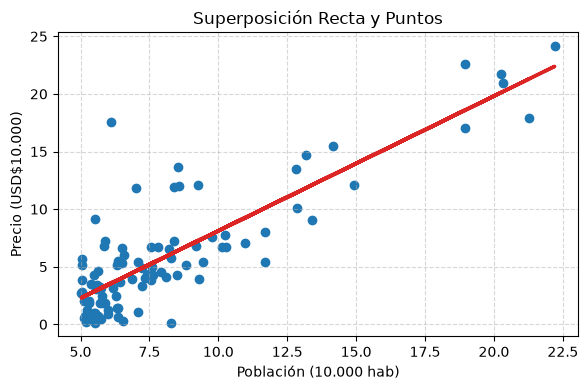

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

datos1 = np.loadtxt('./data/data_1.txt', delimiter=",")
#x1  varibale independiente.
x1 = datos1[:, 0].reshape(-1,1) #Se toma el primer dato de cada fila y reshape permite transformar a un arreglo de una columna con la cantidad de filas que se extrajeron del arreglo original
#y1 variable objetivo
y1 = datos1[:,1]

#Gráfica de dispersión
plt.figure(figsize=(6, 4))
plt.scatter(x1, y1, alpha=1)
plt.title("Gráfica de Dispersión de Puntos")
plt.xlabel("Población (10.000 hab.)")
plt.ylabel("Precio (USD$10.000)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafica_1_puntos.png', dpi=300)
plt.show()
plt.close()

#Ajustamos a regresión lineal
modelo1 = LinearRegression()
modelo1.fit(x1,y1)

#Obtenemos término independiente y pendiente
w0 = modelo1.intercept_
w1 = modelo1.coef_[0]

print("Término independiente ", w0)
print("Pendiente: ", w1)


#Obtenemos los parámetros del modelo
par_modelo = modelo1.get_params()
print("Parámetros del modelo: ", par_modelo)


#Gráfica Regresión
plt.figure(figsize=(6, 4))
plt.plot(x1, modelo1.predict(x1), linewidth=2.5)
plt.title('Recta de Regresión')
plt.xlabel('Población (10.000 hab)')
plt.ylabel('Precio (USD$10.000)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafica_2_recta.png', dpi=300)
plt.show()
plt.close()


#Superposición de gráficas
plt.figure(figsize=(6, 4))
plt.scatter(x1, y1)
plt.plot(x1, modelo1.predict(x1), color='#DC2626', linewidth=2.5)
plt.title('Superposición Recta y Puntos')
plt.xlabel('Población (10.000 hab)')
plt.ylabel('Precio (USD$10.000)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafica_2_recta.png', dpi=300)
plt.show()
plt.close()

1.6: El signo de la pendiente indica que existe una relación positiva entre las variables (a medida que aumenta la población, aumenta el precio de la vivienda). En cuanto a la magnitud, se puede referir que por cada 10.000 habitantes, el precio de las viviendas aumenta, aproximadamente, en un 1,17.

Entrenamiento y prueba con data_2.csv 
Para analizar desempeño sobre datos no utilizados durante el ajuste, dividiremos data_2.csv en un conjunto de entrenamiento y otro de prueba.

Actividad 2
1. Separe los datos en entrenamiento y prueba.
2. Ajuste LinearRegression usando únicamente el conjunto de entrenamiento.
3. Calcule MSE, RMSE y  R2  en ambos conjuntos.
4. Compare los errores y discuta si existe evidencia de un problema de generalización.

In [23]:
#Para esta actvividad asumimos que los datos siguen la línea de la acividad anterior, columna 1 cant hab, columna 2 precio vivienda

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

viviendas_df = pd.read_csv("./data/data_2.csv")
x2 = viviendas_df.iloc[:,[0]] #El método iloc permite tomar todas las filas de la columna, no hace falta reshape porque los dobles corchetes devuelven un arreglo bidimensional
y2 = viviendas_df.iloc[:, 1]

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

#Ajustamos con regresión lineal solo utilizando los datos de entrenamiento
modelo2 = LinearRegression()
modelo2.fit(x2_train, y2_train)

#Predicción y cálculo de métricas
y2_train_pred = modelo2.predict(x2_train) #Se calulan los valores estimados de la variable objetivo, utilizando el set de entrenamiento
y2_test_pred = modelo2.predict(x2_test) #Acá se hace lo mismo, pero con el set de prueba, simulando cómo funcionaría con casos nuevos

#Métricas para el set train
mse2_train = mean_squared_error(y2_train,y2_train_pred) #Se calcula el MSE con los datos y la predicción, luego se calcula el RMSE a partir de este
rmse2_train = np.sqrt(mse2_train)
r2_2train = r2_score(y2_train, y2_train_pred) #Se calcula el valor R2 con los datos y la predicción

#Métricas para el set test
mse2_test = mean_squared_error(y2_test, y2_test_pred)
rmse2_test = np.sqrt(mse2_test)
r2_2test = r2_score(y2_test, y2_test_pred)

print("Métricas Entrenamiento")
print("MSE: ", round(mse2_train,4))
print("RMSE: ", round(rmse2_train, 4)) 
print("R2: ", round(r2_2train,4))
print("Métricas Test")
print("MSE: ", round(mse2_test, 4))
print("RMSE: ", round(rmse2_test,4)) 
print("R2: ", round(r2_2test,4))

Métricas Entrenamiento
MSE:  4.3114
RMSE:  2.0764
R2:  0.9154
Métricas Test
MSE:  4.308
RMSE:  2.0756
R2:  0.9151


Observando los valores R2 de cada set, puede observarse una diferencia insignificante en los mismos, lo que demuestra que el moddelo no está memorizando el ruido (no hay Overfitting)

El ajuste está explicando el 91,5% de la varianza en ambos sets, demostranso que las variables realmente muestran un comportamiento lineal muy marcado (no hay Underfitting)

Aplicación con data_3.csv
Actividad 3
1. Represente los datos.
2. Ajuste modelos polinomiales de grados 1, 3, 7 y 13.
3. Grafique las curvas sobre el mismo conjunto de datos.
4. Compare cómo cambia la forma de la función al aumentar el grado.
5. ¿Puede decidir cuál generaliza mejor mirando únicamente este gráfico? Justifique.

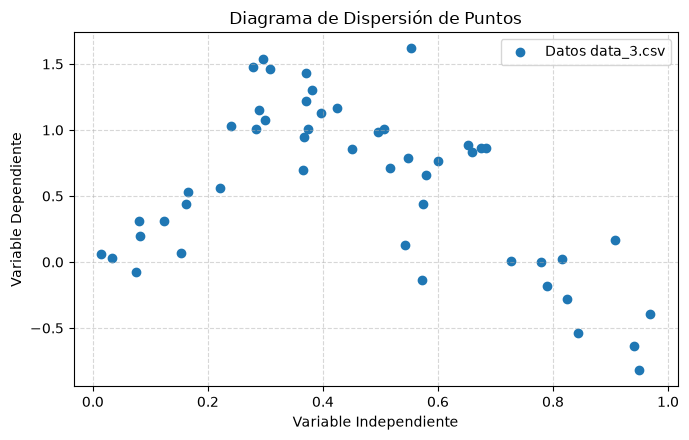

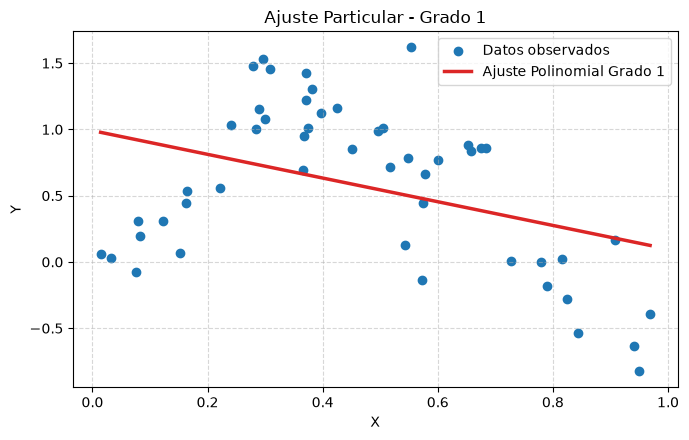

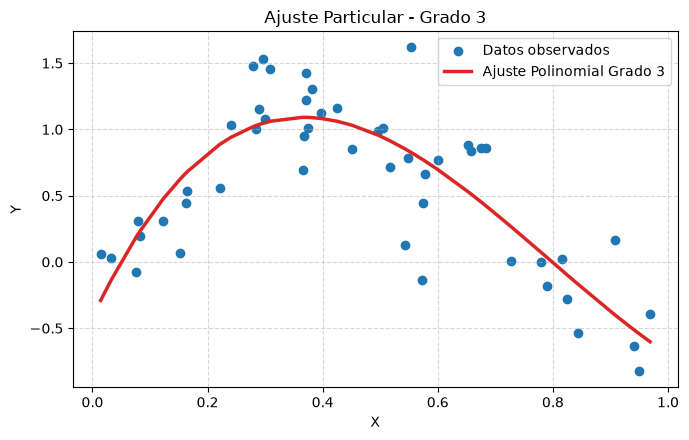

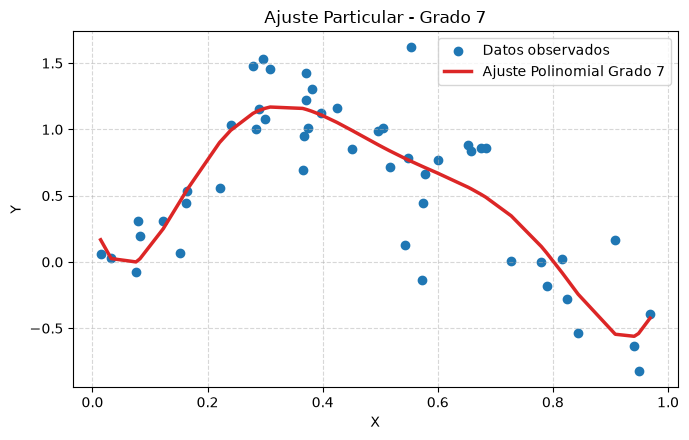

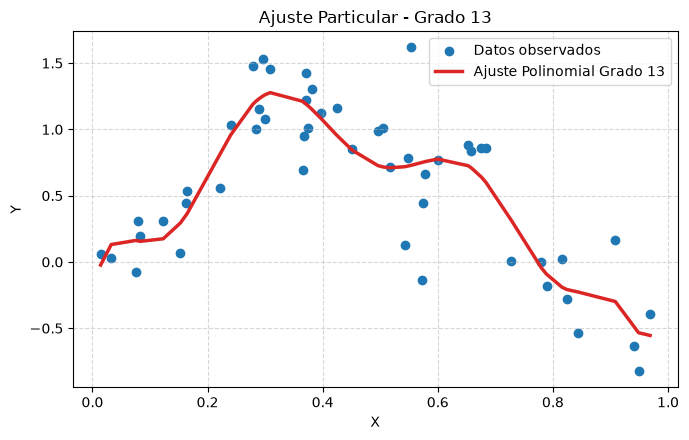

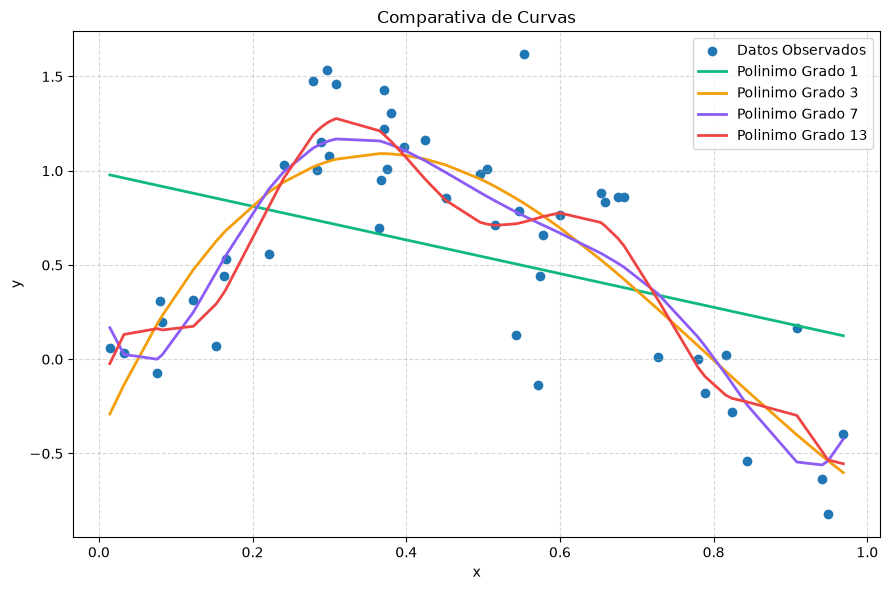

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Cargamos datos
df3 = pd.read_csv("./data/data_3.csv")
x3 = df3[['X']].values.reshape(-1, 1)
y3= df3['Y'].values

#Gráfico de dispersión de puntos para representar los datos
plt.figure(figsize=(7, 4.5))
plt.scatter(x3, y3, label= 'Datos data_3.csv', alpha=1)
plt.title("Diagrama de Dispersión de Puntos")
plt.xlabel('Variable Independiente')
plt.ylabel('Variable Dependiente')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
plt.show()


#Ajustamos a los distintos modelos polinómicos
grados = [1, 3, 7, 13]
modelos_ajustados = {}


for g in grados:
    #Construimos un pipeline
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree = g, include_bias = False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])


    #El pipeline se ajusta con los datos de entrenamiento
    pipeline.fit(x3, y3)
    modelos_ajustados[g] = pipeline
    #Predecimos sobre los datos reales x3
    y_pred = pipeline.predict(x3)

    #Graficamos para las polinomiales de cada grado
    plt.figure(figsize=(7, 4.5))
    plt.scatter(x3, y3, alpha=1, label = "Datos observados")
    plt.plot(x3, y_pred, color = '#DC2626', linewidth =2.5,
            label = f'Ajuste Polinomial Grado {g}')
    plt.title(f'Ajuste Particular - Grado {g}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle = '--', alpha = 0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


#Unificamos las cuatro gráficas
plt.figure(figsize=(9, 6))
plt.scatter(x3, y3, alpha=1, label='Datos Observados')

#Diccionario con colores para mejorar la visualizacion
colores = {1: '#10B981', 3: '#F59E0B', 7: '#8B5CF6', 13: '#EF4444'}

for g in grados:
    pipeline = modelos_ajustados[g]
    y_pred = pipeline.predict(x3)
    plt.plot(x3, y_pred, color=colores[g], linewidth = 2, label= f'Polinimo Grado {g}')

plt.title('Comparativa de Curvas')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


3.4:
La curva de un grado presenta una gran rigides, lo que no permite seguir la curvatura cóncava que describen los puntos. Se puede mencionar un fenómeno de underfitting, dada la falta de flexibilidad.

La curva de grado 3 acompañan la tendencia general del dataset, pasando cerca de la mayoría de los puntos sin presentar ondulaciones no naturales o compartamientos erráticos. Es una curva suave y armónica.

La curva de grado 7 pierde suvidad, adquiere una mayor sensibilidad local a fin de intentar acercarse de forma forzada a puntos de datos específicos.

La curva de grado 13 tiene una flexibilidad caótica y descontrolandose, realizando oscilaciones salvajes hacia arriba y hacia abajo. Puede notarse que el polinomio se amoldó al ruido particular de los puntos, cayendo en u overfitting

3.5:
No parece que ninguna de las curvas generalizara mejor al dataset teniendo en cuenta solo la comparatoria. Aunque pareciera que la curva de grado 13 es la que mejo cumple el trabajo, pueden notarse las violentas oscilaciones en ella, agregar un nuevo valor podría verse afectado por un gran error.
Y auqnue podría intuirse entonces que la de grado 3 posee el comportamiento más estable y razonable, no puede elegirse cual de todos los modelos generaliza mejor sin evaluar el error numérico sobre un conjunto de datos de prueba.